# **CASO DE APLICACIÓN AGRUPAMIENTO: RETAIL (MERCADEO)**

Ustedes hacen parte del equipo de análisis de la información de una empresa de retail. La 
organización está implementando una nueva aplicación que según el equipo de diseño está en 
capacidad de atraer una mayor cantidad de usuarios, siempre y cuando se establezcan medidas de 
comunicación y promoción diferencial dependiendo del tipo de cliente. Ustedes deciden entonces 
implementar un modelo de datos que les permita diferenciar los clientes según su comportamiento 
actuaL.

# Metodología ASUM-DM

1. Entendimiento del negocio: Es una aerolínea que busca entender a sus clientes en particular. El objetivo de negocio es entender las diferencias o particularidades entre clientes para ofrecer modelos o esquemas diferenciados de actuación

2. Entendimiento analítico: Diseñar un experimento que permita agrupar en una cantidad específica de grupos a los clientes de la aerolínea para definir la cantidad de acciones diferenciadas posibles. 

3. Requemiento de datos: Se requieren datos demográficos, datos del servicio prestado al usuario, datos propios del negocio.

4. Recolección de datos: Archivo .csv compartido.

5. Entendimiento de los datos:
- Identificar la existencia de datos nulos
- Exploración univaridad de los datos
- Exploración multivariada de los datos
- Identificación de correlación y multicolinealidad

In [80]:
#Librerías
##Tratamiento estructurado de datos

import pandas as pd
import numpy as np

##Gráficos
import matplotlib.pyplot as plt
import seaborn as sb

##Advertencias
import warnings
warnings.filterwarnings('ignore')

In [81]:
data = pd.read_csv('datos_caso_1.csv', sep=';')
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

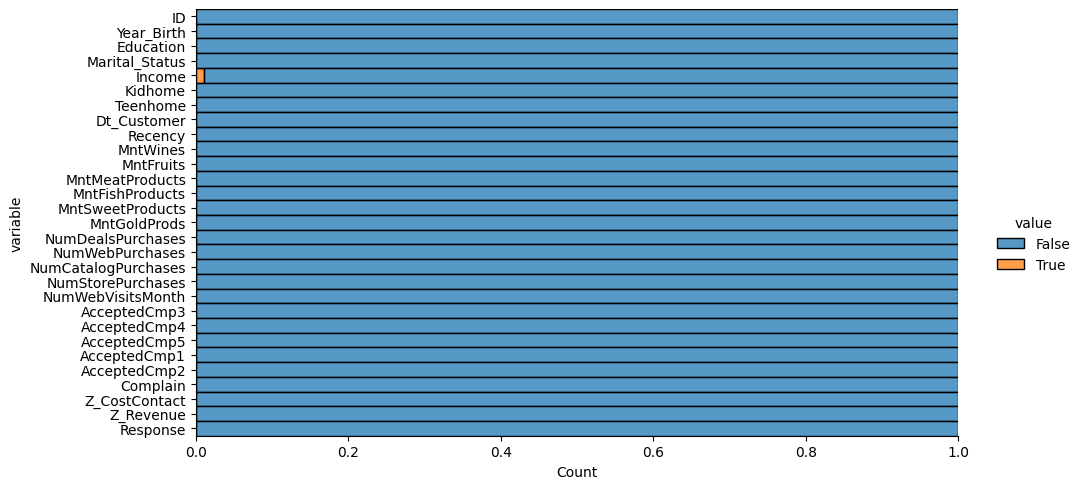

In [83]:
#Visualizar proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

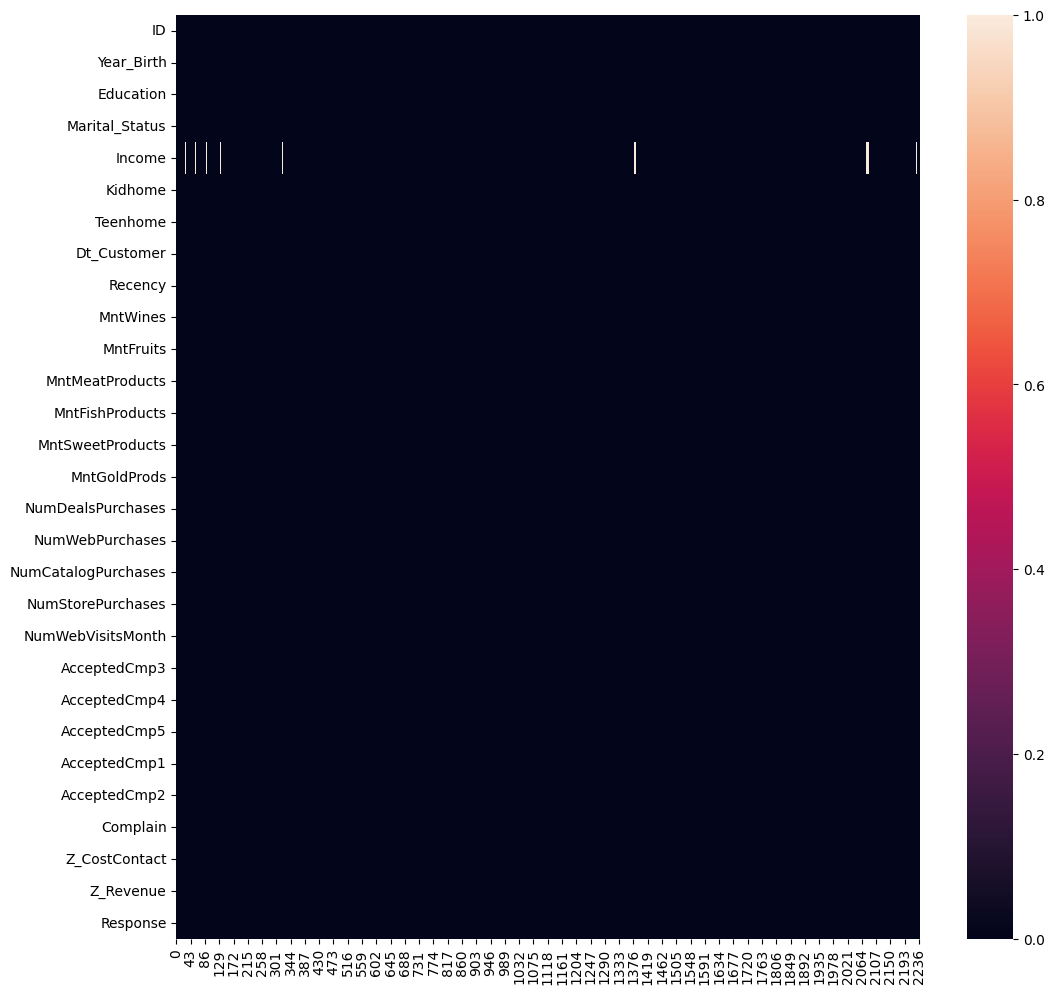

In [84]:
plt.figure(figsize=(12, 12))
data.isnull().transpose().pipe(lambda df: sb.heatmap(data = df))
plt.show()

### Tratamiento datos nulos
1. Eliminar
- Registros: Se eliminan cuando la proporción de eliminación total no supera el 10% de los registros originales.
- Variables: Se eliminan cuando la proporción de nulos en una variable supera el 40%.

2. Imputar
- Simple: Modifica la función de probabilidad
    - Constante: Se define un valor arbitrario para completar los datos nulos por variable.
    - Medidas de tendencia central: Se reemplazan nulos numéricos por media o mediana. Nulos numéricos, por la moda.

- Por modelo: Construye un modelo de machine learning de regresión para completar los datos nulos. Es la mejor estrategia pero es más compleja computacional y matemáticamente.


### Exploración Univariado
1. Variables de comportamiento único
    - Función de probabilidad uniforme --> Se ignoran

2. Sesgos no naturales de la variable
    - Se habla de desbalances. Si una categoría tiene el 80% o más de la proporción de la variable, se habla de desbalance --> Se ignoran


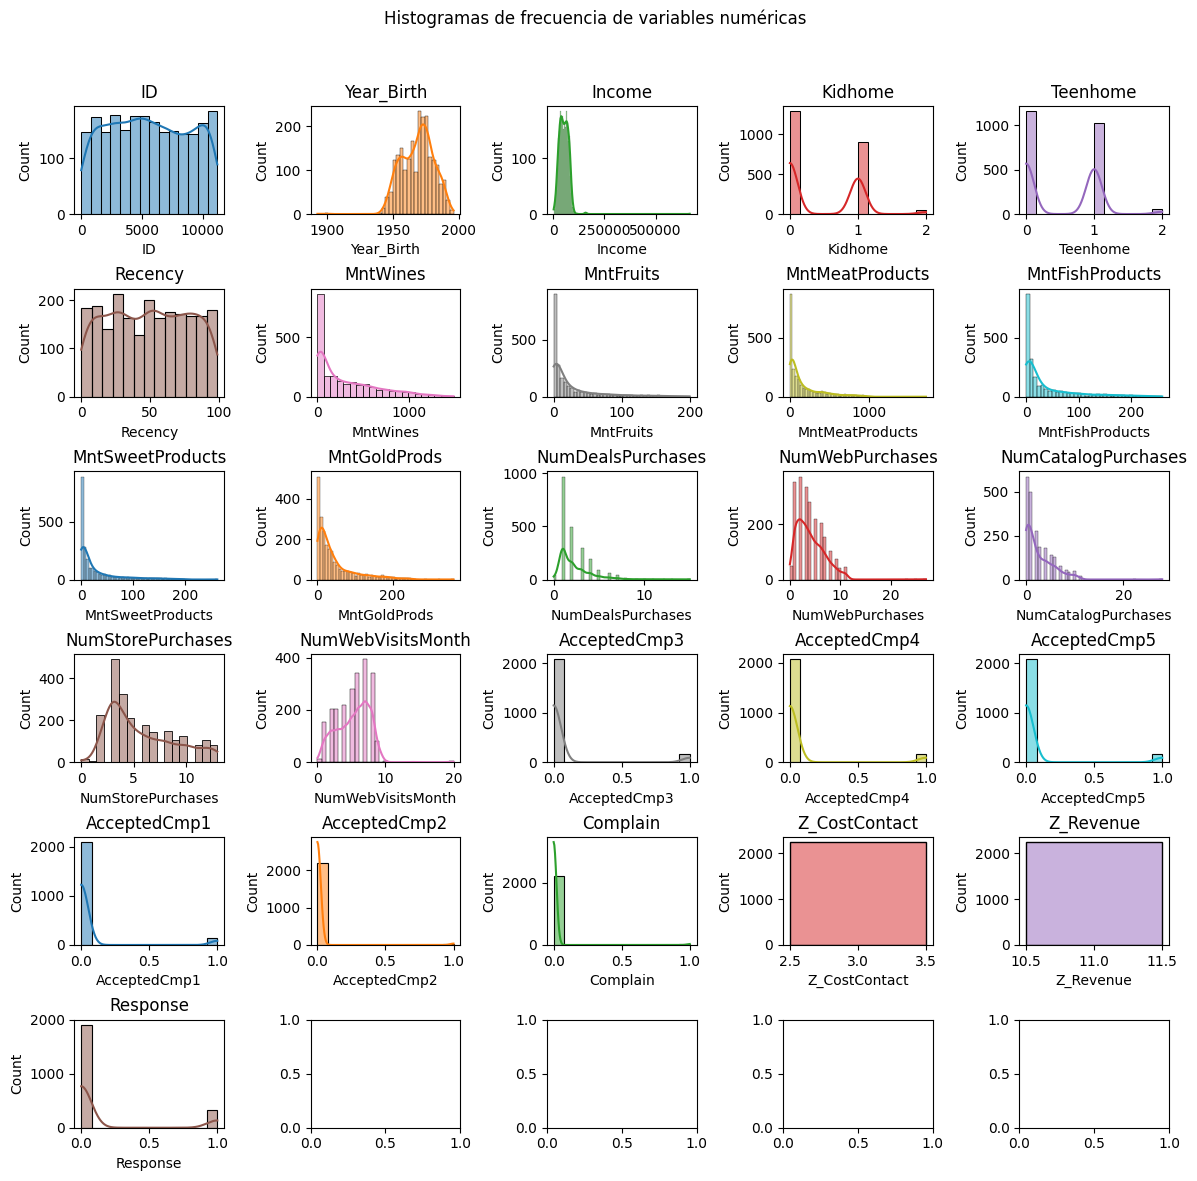

In [85]:
#Exploración univaridad de los datos
##Para datos numéricos: Histogramas de frecuencia
##Para datos categóricos: Gráficos de torta

###HISTOGRAMAS DE FRECUENCIA (Busca variables con distribución uniforme (id, Z_costContact, Z_revenue) o que no aportan información)
fig,ax = plt.subplots(6, 5, figsize=(12, 12))
ax = ax.flat
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
for i, col in enumerate(num_cols):
    sb.histplot(data = data, x = col, kde = True, 
                color = (list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Histogramas de frecuencia de variables numéricas')
plt.show()


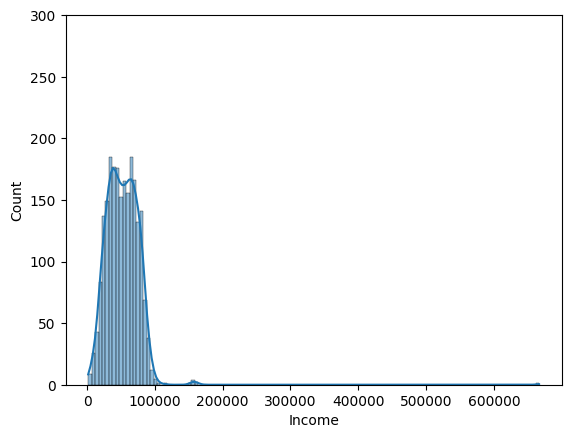

In [86]:
sb.histplot(data = data, x = data['Income'], kde = True)
plt.ylim(0, 300)
plt.show()

In [87]:
#Entender variables categóricas
print(data['Education'].value_counts(), '\n')
print(data['Marital_Status'].value_counts(), '\n')
print(data.Dt_Customer.value_counts(), '\n')

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64 

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Dt_Customer
2012-08-31    12
2014-05-12    11
2013-02-14    11
2012-09-12    11
2014-05-22    10
              ..
2013-11-01     1
2013-08-10     1
2012-10-11     1
2012-12-20     1
2014-01-09     1
Name: count, Length: 663, dtype: int64 



In [88]:
#Convertir variables categóricas a datos con sentido
data['Education'] = data['Education'].replace(['PhD','2n Cycle', 'Master'],'Post Graduate')  
data['Education'] = data['Education'].replace(['Basic', 'Graduation'], 'Under Graduate')
data['Marital_Status'] = data['Marital_Status'].replace(['Married', 'Together'],'Relationship')
data['Marital_Status'] = data['Marital_Status'].replace(['Divorced', 'Widow', 'Alone', 'YOLO', 'Absurd'],'Single')

In [ ]:
data = data.set_index('Dt_Customer')
data.sort_index(inplace=True)
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
Dt_Customer,,,,,,,,,,,,,,,,,,,,,
2012-07-30,6653,1970,Post Graduate,Relationship,55158.0,1,1,72,293,0,...,7,0,0,0,0,0,0,3,11,1
2012-07-31,6181,1950,Post Graduate,Relationship,52203.0,0,0,36,488,21,...,6,0,0,0,0,0,0,3,11,0
2012-08-01,10001,1985,Post Graduate,Relationship,7500.0,1,0,98,5,17,...,9,0,0,0,0,0,0,3,11,0
2012-08-01,4692,1976,Under Graduate,Relationship,7500.0,1,0,19,7,0,...,9,1,0,0,0,0,0,3,11,1
2012-08-01,2611,1959,Post Graduate,Relationship,82576.0,0,0,66,1206,55,...,1,0,0,1,0,0,0,3,11,0


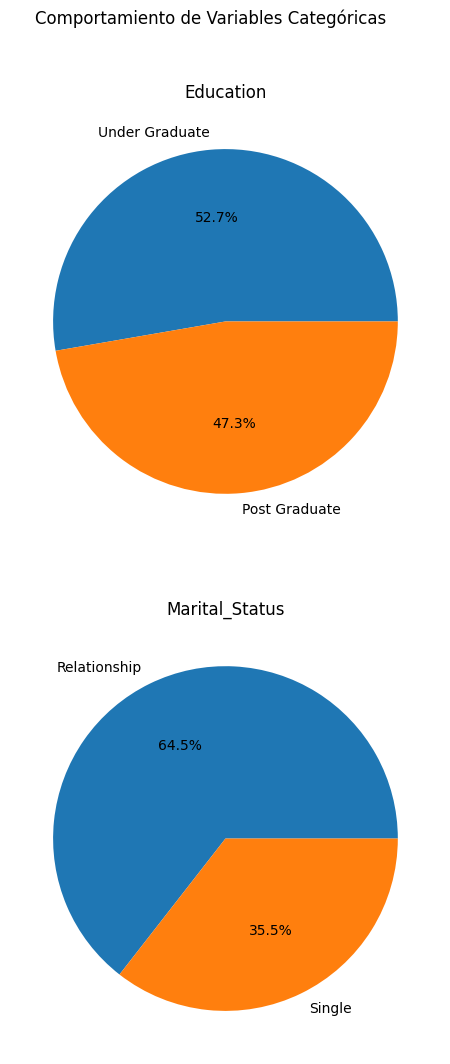

In [90]:
#Gráfico de torta (Busca desbalance en las categorías --> Una categoría tiene más del 80%)
fig, ax = plt.subplots(2, 1, figsize=(12, 12))
ax = ax.flat
cat_cols = data.select_dtypes(include=['object']).columns

for i, col in enumerate(cat_cols):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Categóricas')
plt.show()


### Factor de Correlación
Si el comportamiento de una variable depende linealmente de otra variable. -1 <= Factor correlacón <= 1
La fórmula del factor de correlación de Pearson es:

$$
r_{xy} = \frac{\sqrt{(X_1-\bar{X_1})^2(X_2-\bar{X_2})^2}}{\sqrt{(X_1-\bar{X_1})}\sqrt{(X_2-\bar{X_1})}}
$$

donde $x_i$ y $y_i$ son los valores de las variables, $\bar{x}$ y $\bar{y}$ sus medias, y $n$ el número de observaciones.

- *Factor de correlación > 0*: Correlación directa
- *Factor de correlación < 1*: Correlación inversa
- *-0.25 <= Factor de correlación <= 0.25*: Correlación nula
- *0.25 <= |Factor de correlación| <= 0.5*: Correlación débil
- *0.5 <= |Factor de correlación| <= 0.75*: Correlación moderada
- *0.75 <= |Factor de correlación| <= 1*: Correlación fuerte --> Multicolinealidad

> Si se presenta multicolinealidad, se debe ignorar una de las variables. Se ignora la que tenga mayor correlación con las otras variables.

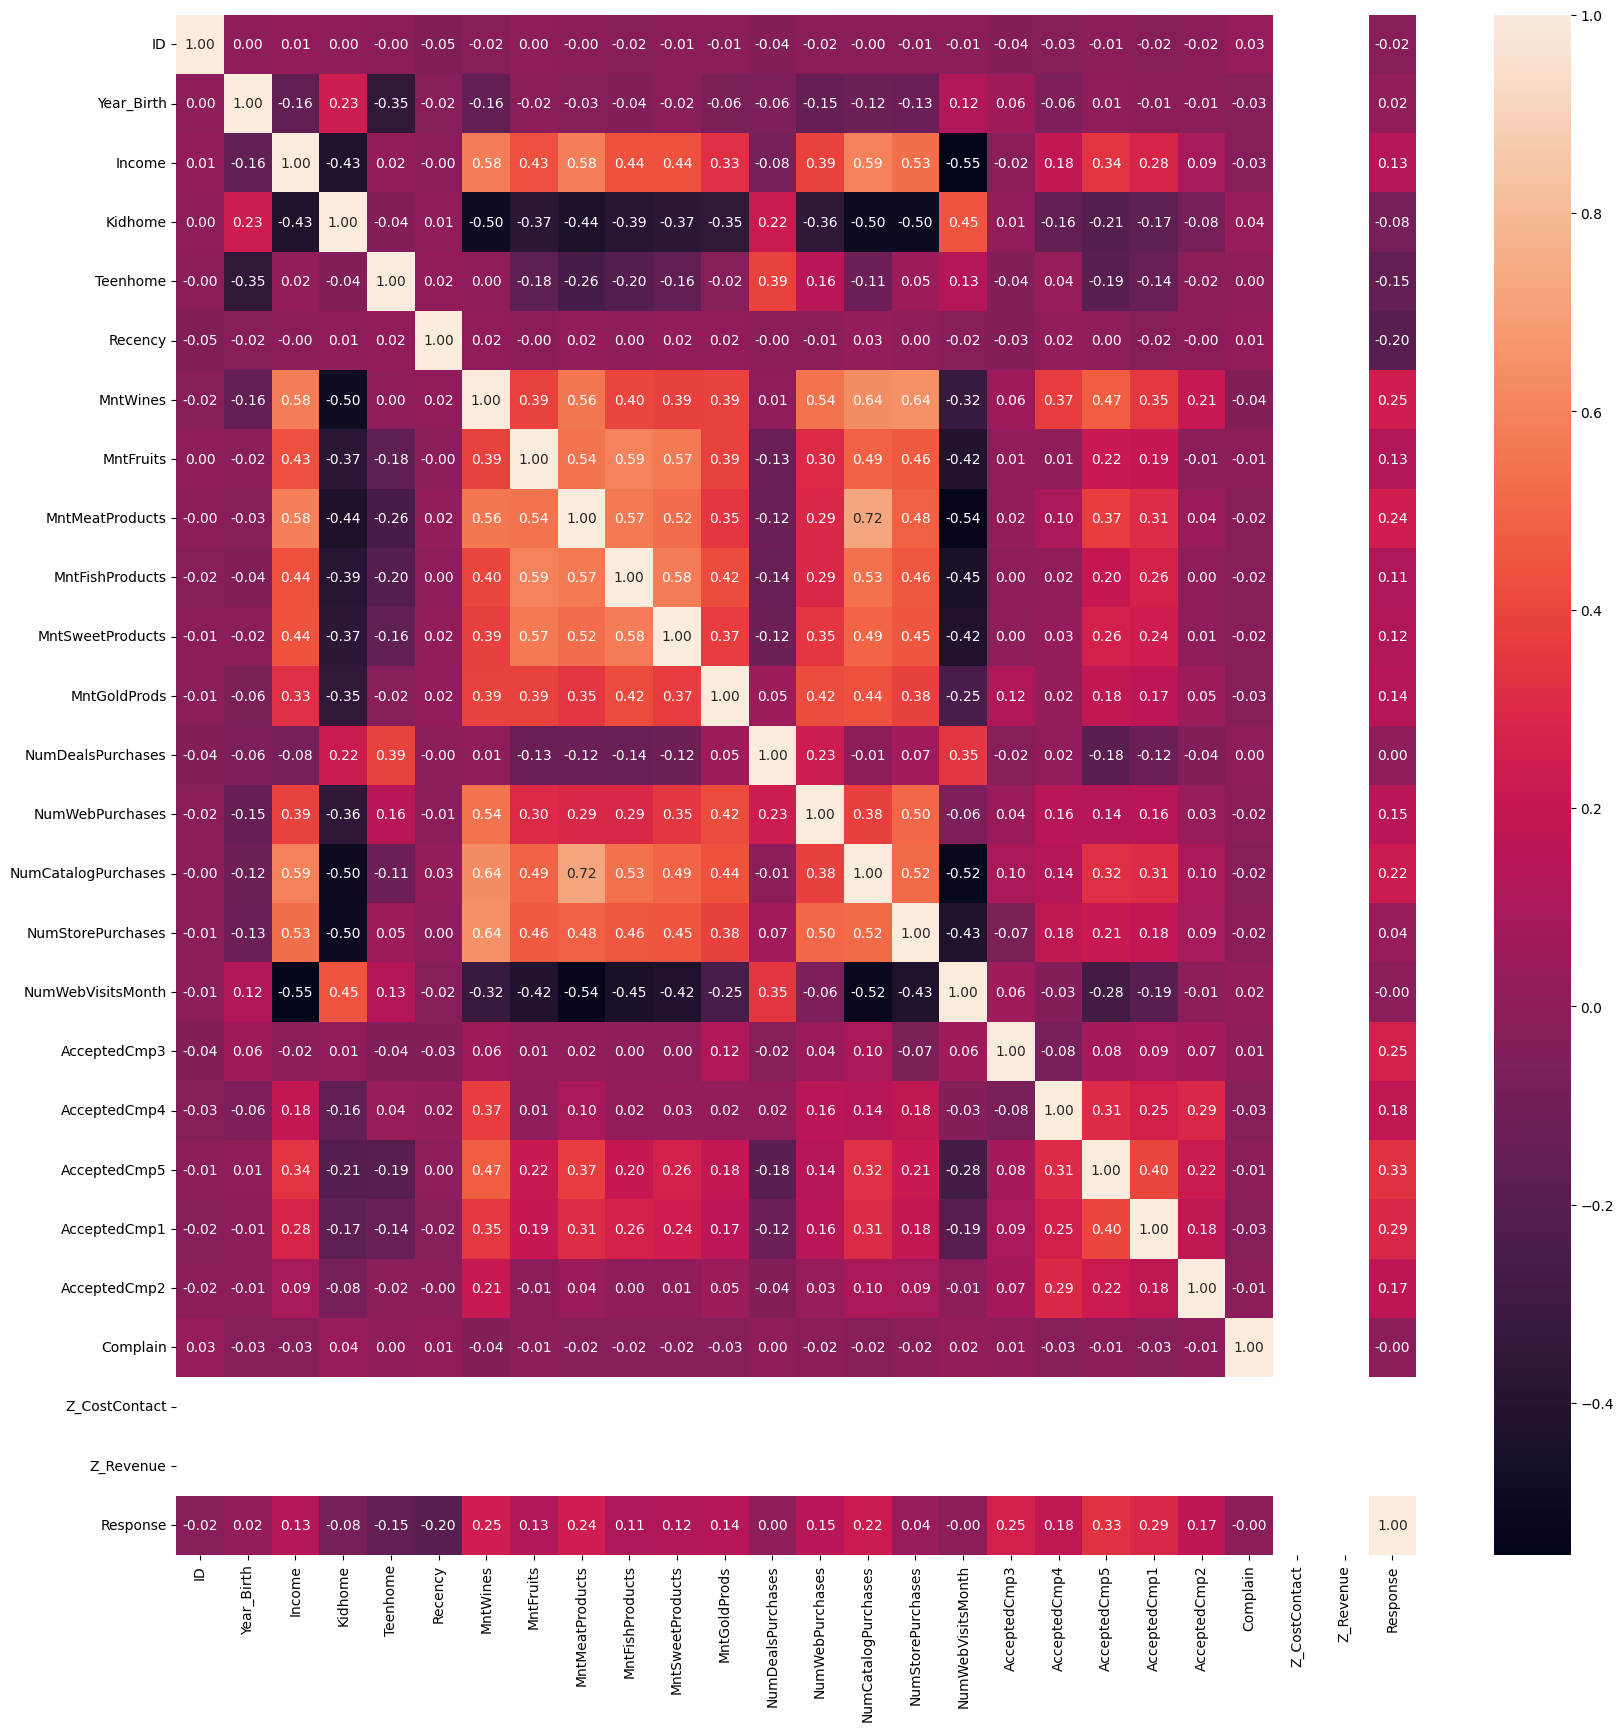

In [91]:
#GRÁFICO DE CORRELACIÓN PARA ANÁLISIS MULTIVARIADO (Busca multicolinealidad)
plt.figure(figsize=(20,20))
sb.heatmap(data = data.corr(numeric_only=True), annot=True, fmt='.2f')
plt.show()

### Conclusiones sobre Variables
- Eliminar registros nulos de Income
- Ignorar id, Z_CostContact, Z_revenue
- Se redujo Marital Status y Education
- Ignorar Dt_costumer

6. Preparación de los Datos
- Activar las decisiones de ignorar variables
- Transformación de variables para que sean entendibles por el modelo

In [134]:
#Ignorar variables que no aportan información
data_mod = data.drop(['ID', 'Z_Revenue', 'Z_CostContact'], axis = 1)



data_mod.info()





<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 2012-07-30 to 2014-06-29
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Recency              2240 non-null   int64  
 7   MntWines             2240 non-null   int64  
 8   MntFruits            2240 non-null   int64  
 9   MntMeatProducts      2240 non-null   int64  
 10  MntFishProducts      2240 non-null   int64  
 11  MntSweetProducts     2240 non-null   int64  
 12  MntGoldProds         2240 non-null   int64  
 13  NumDealsPurchases    2240 non-null   int64  
 14  NumWebPurchases      2240 non-null   int64  
 15  NumCatalogPurchases  2240 no

In [93]:
data_mod.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response'],
      dtype='object')

In [94]:
print(data_mod['Income'].describe())

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64


In [95]:
# Filtrar los valores de Income
data_mod = data_mod[data_mod['Income'] <= 200000] 

In [132]:
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 2012-07-30 to 2014-06-29
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2212 non-null   int64  
 1   Education            2212 non-null   object 
 2   Marital_Status       2212 non-null   object 
 3   Income               2212 non-null   float64
 4   Kidhome              2212 non-null   int64  
 5   Teenhome             2212 non-null   int64  
 6   MntWines             2212 non-null   int64  
 7   MntFruits            2212 non-null   int64  
 8   MntMeatProducts      2212 non-null   int64  
 9   MntFishProducts      2212 non-null   int64  
 10  MntSweetProducts     2212 non-null   int64  
 11  MntGoldProds         2212 non-null   int64  
 12  NumDealsPurchases    2212 non-null   int64  
 13  NumWebPurchases      2212 non-null   int64  
 14  NumCatalogPurchases  2212 non-null   int64  
 15  NumStorePurchases    2212 no

In [96]:
#Eliminar registros nulos de Income
data_mod = data_mod.dropna(subset=['Income'])
print(data_mod.isnull().sum())

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64


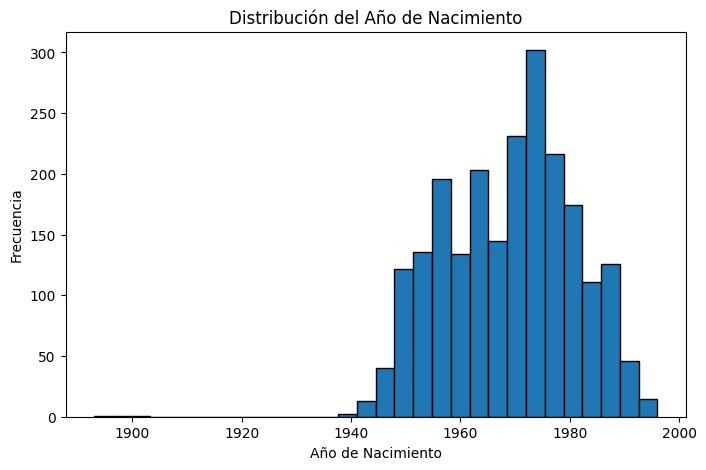

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data_mod['Year_Birth'], bins=30, edgecolor='black')
plt.title('Distribución del Año de Nacimiento')
plt.xlabel('Año de Nacimiento')
plt.ylabel('Frecuencia')
plt.show()


In [98]:
data_mod = data_mod[data_mod['Year_Birth'] >= 1920]

data_mod.columns


Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response'],
      dtype='object')

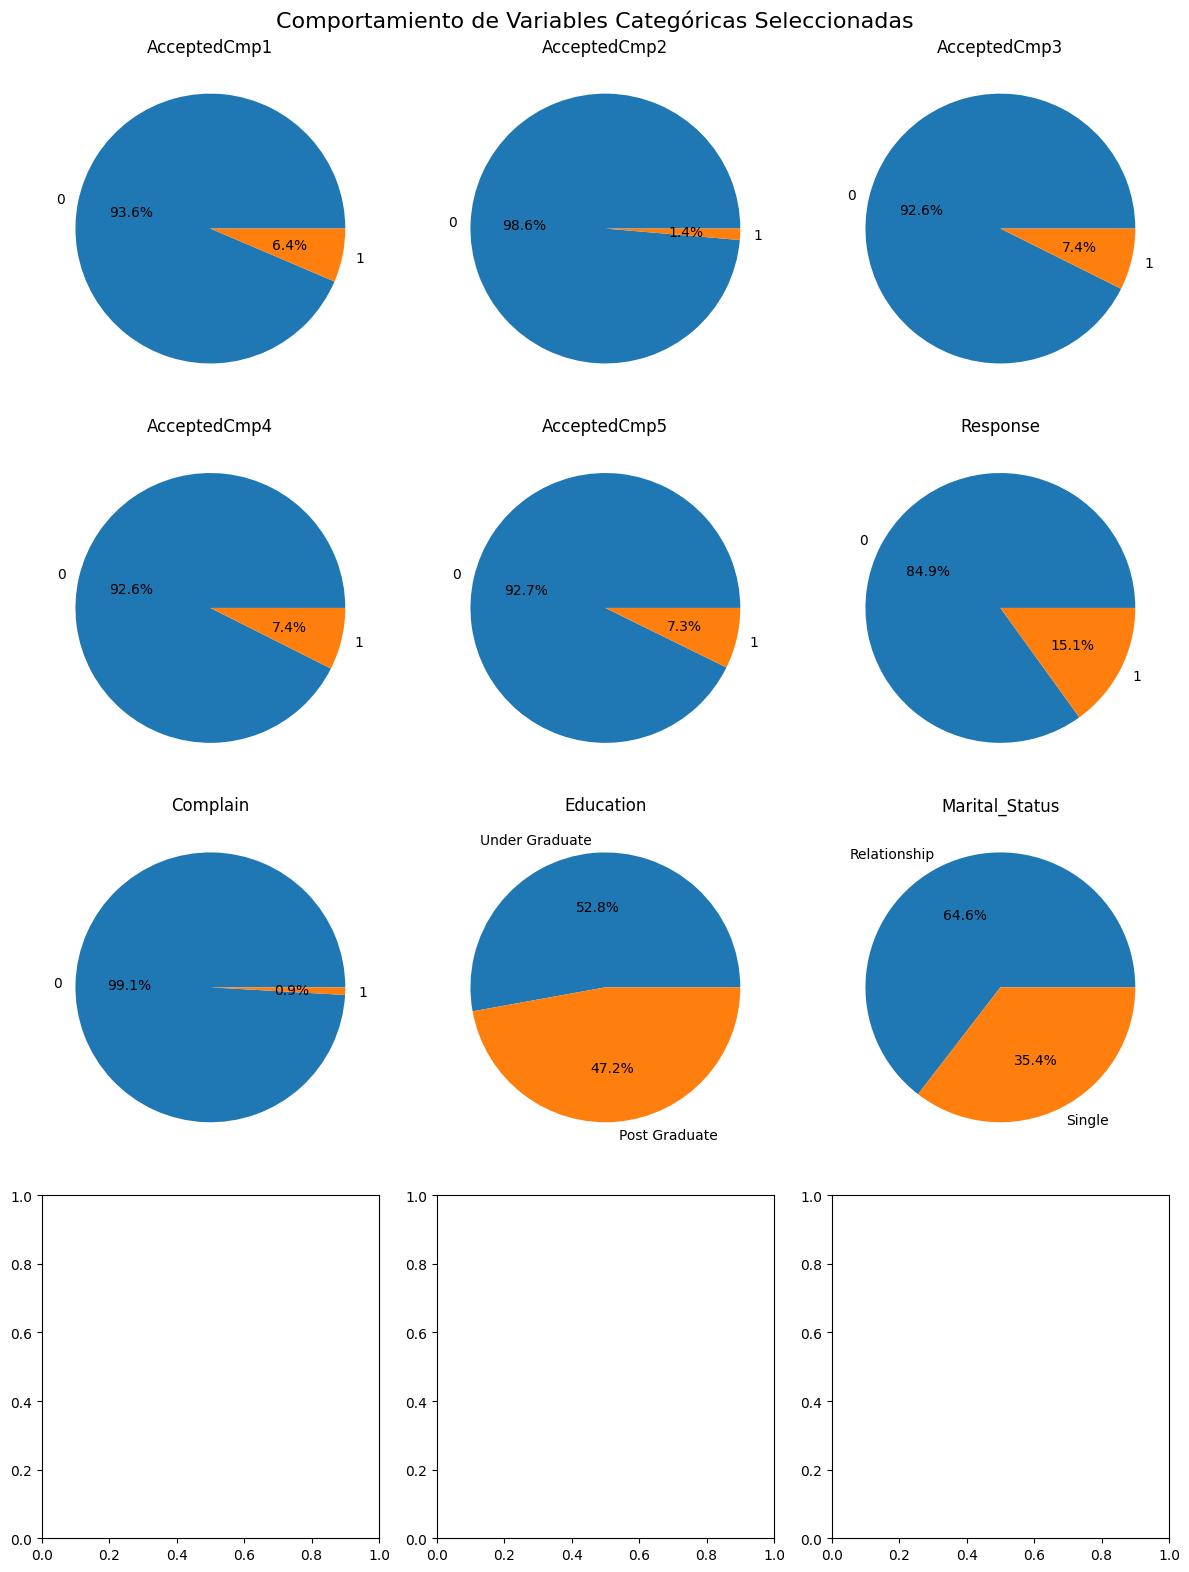

In [99]:
categorical_vars = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain', 'Education', 'Marital_Status']
 
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 16))
axes = axes.flatten()
 
for i, col in enumerate(categorical_vars):
    if i < len(axes):
        axes[i].pie(data_mod[col].value_counts(), labels=data_mod[col].value_counts().index, autopct='%0.1f%%')
        axes[i].set_title(col)
    else:
        # Hide any unused subplots if the number of variables is odd
        fig.delaxes(axes[i])
 
 
fig.tight_layout()
fig.subplots_adjust(top=0.95)
fig.suptitle('Comportamiento de Variables Categóricas Seleccionadas', fontsize=16)
plt.show()

In [100]:
unnecessary_cols = [
     
    'Recency', 
    'AcceptedCmp1', 
    'AcceptedCmp2', 
    'AcceptedCmp3', 
    'AcceptedCmp4', 
    'AcceptedCmp5', 
    'Response', 
    'Complain', 
    
]
data_mod = data_mod.drop(unnecessary_cols, axis=1)
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 2012-07-30 to 2014-06-29
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2212 non-null   int64  
 1   Education            2212 non-null   object 
 2   Marital_Status       2212 non-null   object 
 3   Income               2212 non-null   float64
 4   Kidhome              2212 non-null   int64  
 5   Teenhome             2212 non-null   int64  
 6   MntWines             2212 non-null   int64  
 7   MntFruits            2212 non-null   int64  
 8   MntMeatProducts      2212 non-null   int64  
 9   MntFishProducts      2212 non-null   int64  
 10  MntSweetProducts     2212 non-null   int64  
 11  MntGoldProds         2212 non-null   int64  
 12  NumDealsPurchases    2212 non-null   int64  
 13  NumWebPurchases      2212 non-null   int64  
 14  NumCatalogPurchases  2212 non-null   int64  
 15  NumStorePurchases    2212 no

In [101]:
# Transformación de variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

#Identificar las columnas según su tipo
num_col = data_mod.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_col = data_mod.select_dtypes(include=['object']).columns.to_list()

#Tipo de transformación por tipo de dato
num_transformer = Pipeline(steps=[('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps=[('encoder', OneHotEncoder())])

#Diseño del transformador de columnas
preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_col),
                                               ('cat', cat_transformer, cat_col)],
                                               remainder='passthrough')
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [102]:
data_pre = preprocessor.fit_transform(data_mod)
data_pre

array([[0.53571429, 0.33253873, 0.5       , ..., 0.        , 1.        ,
        0.        ],
       [0.17857143, 0.31414665, 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.80357143, 0.03591279, 0.5       , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.25      , 0.42753646, 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.21428571, 0.41957589, 0.        , ..., 1.        , 0.        ,
        1.        ],
       [0.28571429, 0.20919044, 0.5       , ..., 0.        , 0.        ,
        1.        ]], shape=(2212, 19))

In [103]:
cod_cat = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])
data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro.head()

,Year_Birth,Income,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Education_Post Graduate,Education_Under Graduate,Marital_Status_Relationship,Marital_Status_Single
0,0.535714,0.332539,0.5,0.5,0.196249,0.000000,0.050435,0.015444,0.041985,0.071651,0.266667,0.259259,0.071429,0.384615,0.35,1.0,0.0,1.0,0.0
1,0.178571,0.314147,0.0,0.0,0.326859,0.105528,0.137971,0.216216,0.412214,0.087227,0.066667,0.296296,0.250000,0.846154,0.30,1.0,0.0,1.0,0.0
2,0.803571,0.035913,0.5,0.0,0.003349,0.085427,0.009855,0.050193,0.053435,0.105919,0.266667,0.074074,0.035714,0.230769,0.45,1.0,0.0,1.0,0.0
3,0.642857,0.035913,0.5,0.0,0.004689,0.000000,0.006957,0.050193,0.026718,0.099688,0.333333,0.148148,0.035714,0.153846,0.45,0.0,1.0,1.0,0.0
4,0.339286,0.503190,0.0,0.0,0.807770,0.276382,0.257971,0.648649,0.068702,0.056075,0.066667,0.074074,0.142857,0.923077,0.05,1.0,0.0,1.0,0.0


In [ ]:
data_pro.info()

data_pro.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2212 entries, 0 to 2211
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year_Birth                   2212 non-null   float64
 1   Income                       2212 non-null   float64
 2   Kidhome                      2212 non-null   float64
 3   Teenhome                     2212 non-null   float64
 4   MntWines                     2212 non-null   float64
 5   MntFruits                    2212 non-null   float64
 6   MntMeatProducts              2212 non-null   float64
 7   MntFishProducts              2212 non-null   float64
 8   MntSweetProducts             2212 non-null   float64
 9   MntGoldProds                 2212 non-null   float64
 10  NumDealsPurchases            2212 non-null   float64
 11  NumWebPurchases              2212 non-null   float64
 12  NumCatalogPurchases          2212 non-null   float64
 13  NumStorePurchases 

Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Education_Post Graduate', 'Education_Under Graduate',
       'Marital_Status_Relationship', 'Marital_Status_Single', 'DBSCAN',
       'Cluster_KMeans', 'Cluster_HClust', 'Cluster_DBSCAN', 'Cluster_GMM'],
      dtype='object')

7. Construcción del modelo

**K Means**

In [104]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

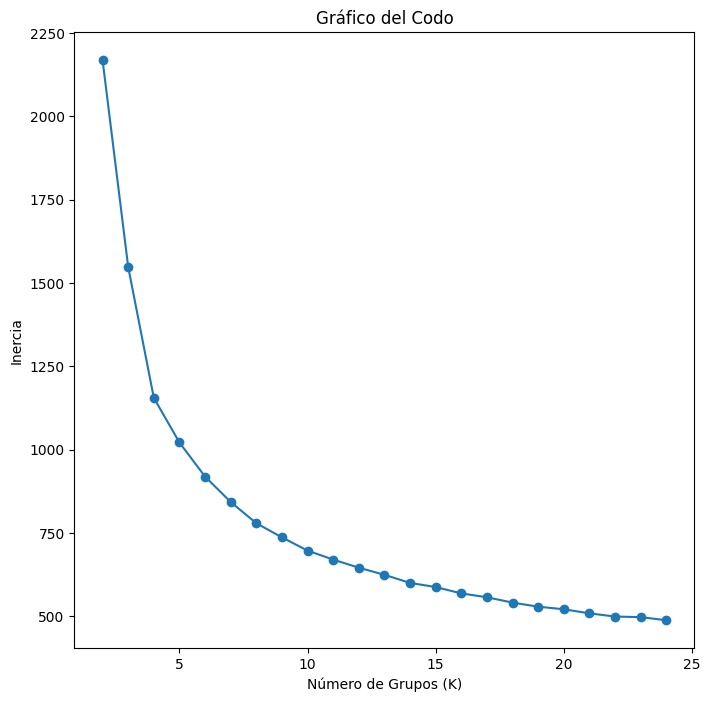

In [105]:
#Buscar el rango para K (busca el codo)
range_k = range(2, 25)
inertia = []

for n_clusters in range_k:
    kmean_model = KMeans(n_clusters=n_clusters, n_init=20, random_state=123)
    kmean_model.fit(data_pro)
    inertia.append(kmean_model.inertia_)
    
plt.figure(figsize=(8, 8))
plt.plot(range_k, inertia, marker='o')
plt.title("Gráfico del Codo")
plt.xlabel("Número de Grupos (K)")
plt.ylabel("Inercia")
plt.show()

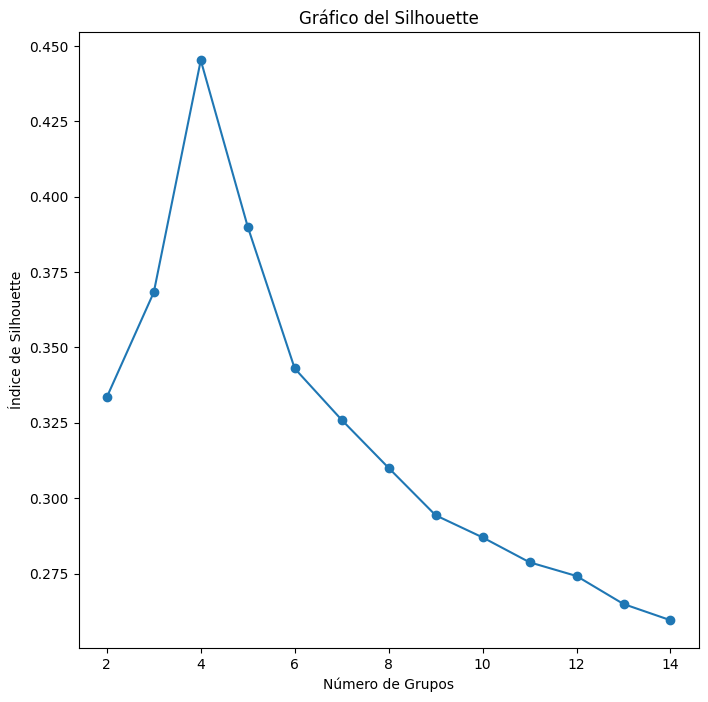

In [106]:
#Búsqueda fina de k (dado el rango de codo, toma el válor de max índice)
range_k = range(2, 15)
sil_score = []

for n_clusters in range_k:
    kmean_model = KMeans(n_clusters=n_clusters, n_init=20, random_state=123)
    kmean_model.fit(data_pro)
    cluster_label = kmean_model.fit_predict(data_pro)
    sil_avg = silhouette_score(data_pro, cluster_label)
    sil_score.append(sil_avg)
    
plt.figure(figsize=(8, 8))
plt.plot(range_k, sil_score, marker='o')
plt.title("Gráfico del Silhouette")
plt.xlabel("Número de Grupos")
plt.ylabel("Índice de Silhouette")
plt.show()

In [107]:
# Selección del número óptimo de clusters
k_mean_model_final = KMeans(n_clusters=5, n_init=20, random_state=123)
k_mean_model_final.fit(data_pro)

,n_clusters,5
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,123
,copy_x,True
,algorithm,'lloyd'


**Jerárquico Aglomerativo**

In [108]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

#Función para dibujar el dendrograma
def dibujarDendrograma(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
 
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
 
    # Plot
    dendrogram(linkage_matrix, **kwargs)

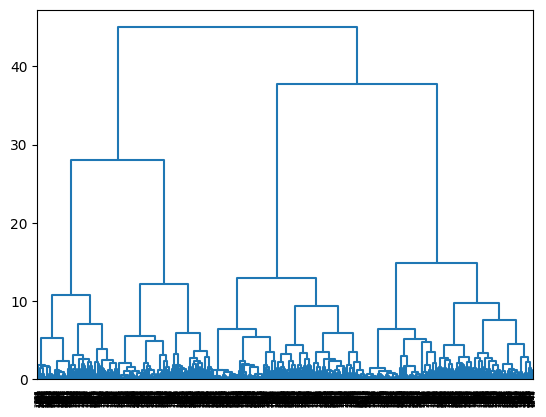

In [109]:
#Varianza
h_clust_ward = AgglomerativeClustering(metric='euclidean', linkage='ward', distance_threshold=0, n_clusters=None)
h_clust_ward.fit(X = data_pro)
dibujarDendrograma(h_clust_ward, color_threshold=0)

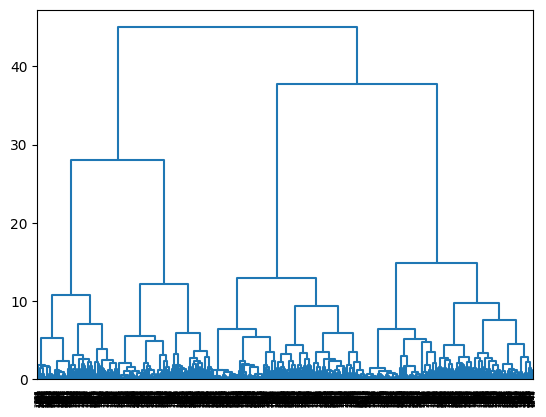

In [110]:
#Promedio
h_clust_average = AgglomerativeClustering(metric='euclidean', linkage='average', distance_threshold=0, n_clusters=None)
h_clust_average.fit(X = data_pro)
dibujarDendrograma(h_clust_ward, color_threshold=0)

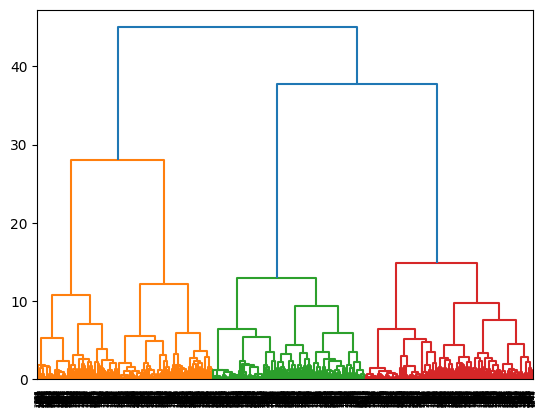

In [111]:
dendogram_prun = 34       #Distancia seleccionada cortando a la mitad la línea más larga del dendrograma
dibujarDendrograma(h_clust_ward, color_threshold=dendogram_prun)

In [112]:
h_clust_final = AgglomerativeClustering(metric='euclidean', linkage='ward', n_clusters=3)
h_clust_final.fit(X = data_pro)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


**DBScan**

In [113]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from itertools import product

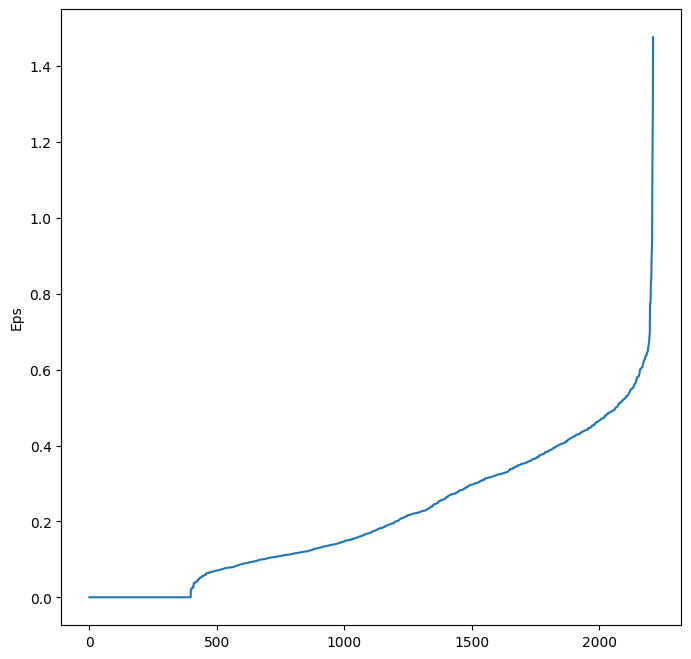

In [114]:
neighbors = NearestNeighbors(n_neighbors=3)
neighbors_fit = neighbors.fit(data_pro)
distance, index = neighbors_fit.kneighbors(data_pro)
distance = np.sort(distance, axis=0)
distance = distance[:, 1]
plt.figure(figsize=(8, 8))
plt.ylabel("Eps")
plt.plot(distance)

In [115]:
sil_score = []
for p in dbscan_params:
    y_pred = DBSCAN(eps=p[0], min_samples=p[1]).fit_predict(data_pro)
    # Validar que haya al menos 2 clusters válidos (excluyendo ruido -1)
    if len(set(y_pred)) > 1 and len(set(y_pred)) != 1:
        sil_score.append(silhouette_score(data_pro, y_pred))
    else:
        sil_score.append(-1)  # Marcamos -1 para indicar que no es válido


<Axes: xlabel='Epsilon', ylabel='Mínimas Muestras'>

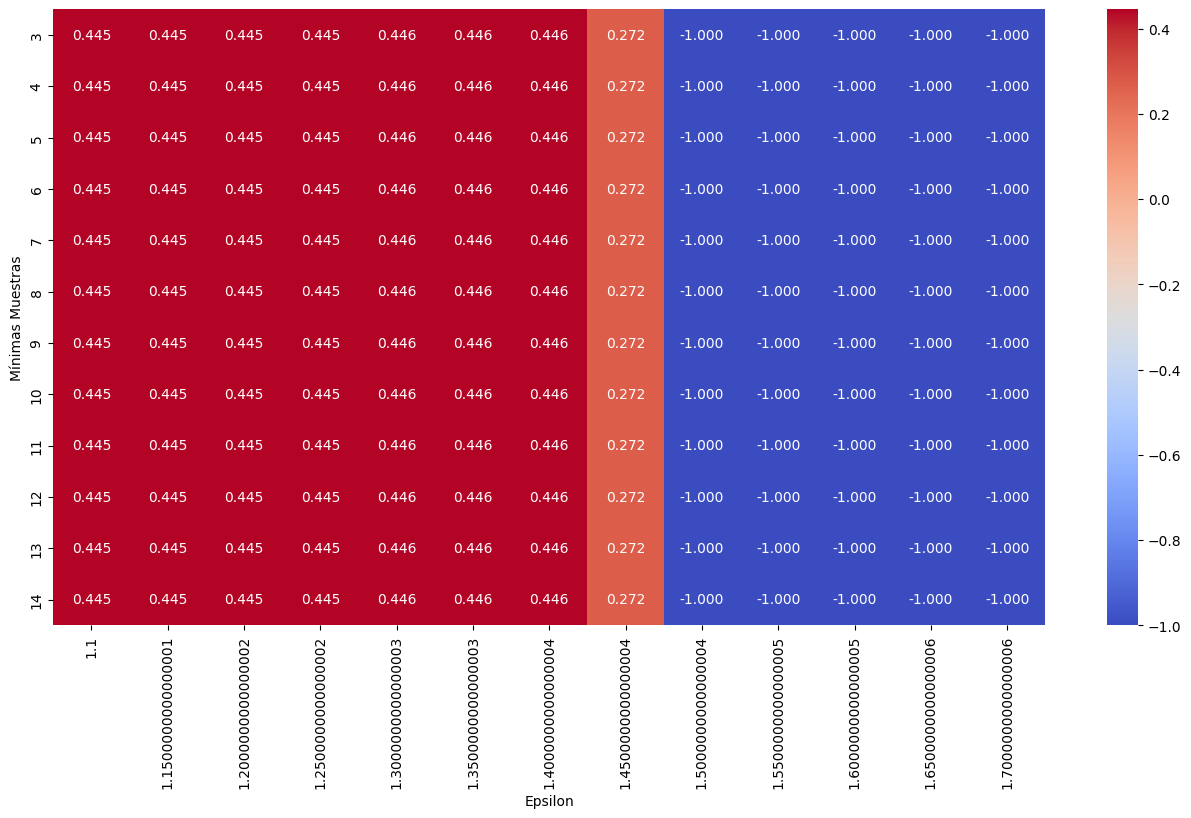

In [116]:
df_param_adj = pd.DataFrame(dbscan_params, columns=['Epsilon', 'Mínimas Muestras'])
df_param_adj['Score'] = sil_score
pivot_data = pd.pivot_table(df_param_adj, values='Score', index='Mínimas Muestras', columns='Epsilon')
plt.figure(figsize=(16, 8))
sb.heatmap(data=pivot_data, annot=True, fmt='.3f', cmap='coolwarm')

## Se debe seleccionar el mejor parámetro de eps y min_samples basado en el score más alto. En caso de score iguales, 
# se debe seleccionar el de menor mínimas muestras

In [117]:
dbscan_final = DBSCAN(eps=1.25, min_samples=10)
dbscan_final.fit(data_pro)

,eps,1.25
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


**Gaussian Mixture Models (GMM)**

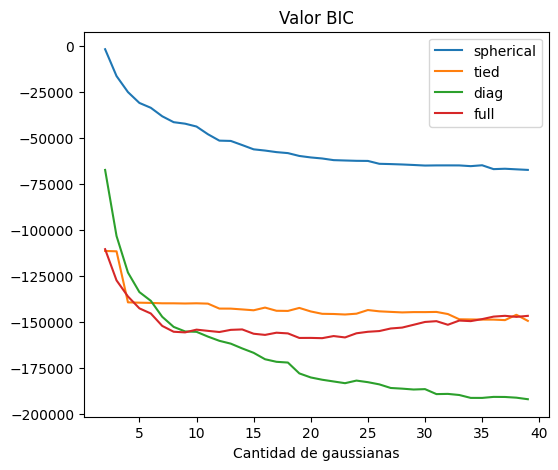

In [118]:
from sklearn.mixture import GaussianMixture
fig, ax = plt.subplots(figsize=(6,5))
n_gauss = range(2, 40)
var_types = ['spherical', 'tied', 'diag', 'full']
''' Spherical: La proyección en 2D es un círculo, la varianza es la misma en todas las direcciones.
    Tied: Misma varianza para todas las gaussianas
    Diagonal: Varianza según una de las variables o características de los datos
    Full: Deja libre la varianza de cada gaussiana, es decir, cada gaussiana puede tener una forma diferente.'''
for covariance_type in var_types:
    valor_bic = []
    for i in n_gauss:
        modelo = GaussianMixture(n_components=i, covariance_type=covariance_type, random_state=123)
        modelo.fit(data_pro)
        valor_bic.append(modelo.bic(data_pro))
        
    ax.plot(n_gauss, valor_bic, label=covariance_type)
ax.set_title('Valor BIC')
ax.set_xlabel('Cantidad de gaussianas')
ax.legend()
plt.show()
#Se debe serleccionar el mínimo BIC (eje Y) y el número de gaussianas (eje X) que lo produce.

In [119]:
gmm_final = GaussianMixture(n_components=39, covariance_type='diag', random_state=123)
gmm_final.fit(data_pro)

,n_components,39
,covariance_type,'diag'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,123


8. Evaluación del Modelo

In [120]:
labels_kmeans = k_mean_model_final.predict(data_pro)
labels_hclust = h_clust_final.fit_predict(data_pro)
labels_dbscan = dbscan_final.fit_predict(data_pro)
labels_gmm = gmm_final.predict(data_pro)

In [121]:
sil_kmeans = silhouette_score(data_pro, labels_kmeans)
sil_hclust = silhouette_score(data_pro, labels_hclust)
sil_dbscan = silhouette_score(data_pro, labels_dbscan)
sil_gmm = silhouette_score(data_pro, labels_gmm)
print(f'El índice de Silhouette para:\nKMeans = {sil_kmeans:.3f} \nJerárquico = {sil_hclust:.3f} \nDBScan = {sil_dbscan:.3f} \nGMM = {sil_gmm:.3f}')
#Si DBSCAN tiene un mayor score, es necesario revisar la cantidad de grupos

El índice de Silhouette para:
KMeans = 0.390 
Jerárquico = 0.368 
DBScan = 0.445 
GMM = 0.163


In [122]:
np.unique(labels_dbscan)
#-1 es punto de ruido, los demás son grupos. Se debe contar la cantidad de ruido

array([-1,  0,  1,  2,  3])

In [123]:
data_pro['DBSCAN'] = labels_dbscan

In [124]:
data_pro.DBSCAN.value_counts()
# Revisar cantidad de ruido (-1). Este número debe ser bajo.

DBSCAN
 1    746
 0    679
 3    422
 2    361
-1      4
Name: count, dtype: int64

# Conclusión
Los algoritmos con índice de Sillohouette más altos son DBScan y Kmean. DBScan separa la muestra en 4 grupos y 69 individuos (73 grupos en total). Esto se vuelve impráctico y se elige Kmean, que culsteriza la muestra en 5 grupos. Se rechaza la hipótesis de que se puede dividir en 3.

In [125]:
# Prueba de mejor modelo con 3 grupos
k_mean_model_test = KMeans(n_clusters=3, n_init=20, random_state=123)
k_mean_model_test.fit(data_pro)
labels_kmeans_test = k_mean_model_test.fit_predict(data_pro)
sil_kmeans_test = silhouette_score(data_pro, labels_kmeans_test)
print(f'Índice de Silhouette para KMeans con 3 grupos: {sil_kmeans_test:.3f}')

Índice de Silhouette para KMeans con 3 grupos: 0.486


Con 3 grupos, K means arroja un índico de Silhouette similar al jerárquico con también 3 grupos e inferior al de DBScan K means con 5 grupos. 

In [126]:
data_pro['Cluster_KMeans'] = labels_kmeans
data_pro['Cluster_HClust'] = labels_hclust
data_pro['Cluster_DBSCAN'] = labels_dbscan
data_pro['Cluster_GMM'] = labels_gmm

# Contar elementos en cada cluster
print(data_pro['Cluster_KMeans'].value_counts())
print(data_pro['Cluster_HClust'].value_counts())
print(data_pro['Cluster_DBSCAN'].value_counts())
print(data_pro['Cluster_GMM'].value_counts())


Cluster_KMeans
0    681
1    424
2    422
3    362
4    323
Name: count, dtype: int64
Cluster_HClust
0    784
1    749
2    679
Name: count, dtype: int64
Cluster_DBSCAN
 1    746
 0    679
 3    422
 2    361
-1      4
Name: count, dtype: int64
Cluster_GMM
10    181
12    155
4     137
30    133
29    116
17    107
0     104
2     102
18     97
1      96
34     95
9      93
32     86
3      69
23     60
25     53
15     51
24     50
36     49
35     43
8      42
22     41
38     36
5      35
13     28
33     21
31     20
20     19
37     16
14     13
11     12
6      11
19     10
7       7
28      6
27      6
21      4
26      4
16      4
Name: count, dtype: int64


In [127]:
# Agregar las etiquetas de clusters al dataset original (no escalado)
data_mod['Cluster_KMeans'] = labels_kmeans
data_mod['Cluster_HClust'] = labels_hclust

# --- Función para obtener estadísticos por cluster ---
def cluster_summary(df, cluster_col):
    """
    Devuelve un resumen con la media y mediana de cada variable
    para cada cluster.
    """
    mean_summary = df.groupby(cluster_col).mean(numeric_only=True)
    median_summary = df.groupby(cluster_col).median(numeric_only=True)
    return mean_summary, median_summary

# --- Resumen para KMeans ---
mean_kmeans, median_kmeans = cluster_summary(data_mod, 'Cluster_KMeans')

# --- Resumen para Jerárquico ---
mean_hclust, median_hclust = cluster_summary(data_mod, 'Cluster_HClust')

# Mostrar resultados
print("=== RESUMEN KMEANS - MEDIAS ===")
print(mean_kmeans)
print("\n=== RESUMEN KMEANS - MEDIANAS ===")
print(median_kmeans)

print("\n=== RESUMEN HCLUST - MEDIAS ===")
print(mean_hclust)
print("\n=== RESUMEN HCLUST - MEDIANAS ===")
print(median_hclust)


=== RESUMEN KMEANS - MEDIAS ===
                 Year_Birth        Income   Kidhome  Teenhome    MntWines  \
Cluster_KMeans                                                              
0               1967.907489  53353.035242  0.441997  0.550661  332.540382   
1               1971.808962  35443.783019  0.764151  0.481132   70.799528   
2               1970.383886  50974.943128  0.426540  0.445498  265.464455   
3               1967.325967  53407.908840  0.417127  0.524862  360.063536   
4               1967.092879  70359.811146  0.065015  0.501548  546.278638   

                MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster_KMeans                                                                  
0               21.914831       153.666667        31.108664         22.255507   
1                6.839623        38.103774        10.245283          6.929245   
2               32.028436       175.080569        42.381517         30.407583   
3               22.9005

In [128]:
# Contar clusters únicos (sin contar el ruido en DBSCAN)
num_clusters_kmeans = len(np.unique(labels_kmeans))
num_clusters_hclust = len(np.unique(labels_hclust))
num_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
num_clusters_gmm = len(np.unique(labels_gmm))

print(f"Número de clusters:")
print(f"KMeans: {num_clusters_kmeans}")
print(f"Jerárquico: {num_clusters_hclust}")
print(f"DBSCAN: {num_clusters_dbscan} (excluyendo ruido)")
print(f"GMM: {num_clusters_gmm}")

# Contar cuántos puntos son ruido en DBSCAN
if -1 in labels_dbscan:
    ruido = np.sum(labels_dbscan == -1)
    print(f"Puntos clasificados como ruido en DBSCAN: {ruido}")


Número de clusters:
KMeans: 5
Jerárquico: 3
DBSCAN: 4 (excluyendo ruido)
GMM: 39
Puntos clasificados como ruido en DBSCAN: 4
